<a href="https://colab.research.google.com/github/Maestro-Titarenko/EconometricsProblemSets/blob/ECON771/PS2_Ziyu_Yan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Econ 771 - Problem Set 2

In [3]:
# Import necessary packages
import pandas as pd

###

<b>

Hayashi, Empirical exercise (a)-(h), p. 76-81

<br>

<blockquote>

Read Marc Nerlove, “Returns to Scale in Electricity Supply” (except paragraphs of equations (6)–(9), the part of section 2 from p. 184 on, and Appendix A and C) before doing this exercise. For 145 electric utility companies in 1955, the file NERLOVE.ASC has data on the following:

Column 1: total costs (call it $TC$) in millions of dollars

Column 2: output ($Q$) in billions of kilowatt hours

Column 3: price of labor ($PL$)

Column 4: price of fuels ($PF$)

Column 5: price of capital ($PK$).

They are from the data appendix of his article. There are 145 observations, and the observations are ordered in size, observation 1 being the smallest company and observation 145 the largest. Using the data transformation facilities of your computer software, generate for each of the 145 firms the variables required for estimation. To estimate (1.7.4), for example, you need to generate $\log(TC)$, a constant, $\log(Q)$, $\log(PL)$, $\log(PK)$, and $\log(PF)$, for each of the 145 firms.

</blockquote>

</b>

In [4]:
# I found the dta version data here: http://fmwww.bc.edu/ec-p/data/Hayashi/
# One can also find the src or excel data from his website: http://fhayashi.fc2web.com/datasets.htm
ps2_data = pd.read_stata("http://fmwww.bc.edu/ec-p/data/Hayashi/nerlove63.dta")

# Load first few lines to have a feeling of the data
print(ps2_data.head())

   totcost  output  plabor      pfuel   pkap
0    0.082     2.0    2.09  17.900000  183.0
1    0.661     3.0    2.05  35.099998  174.0
2    0.990     4.0    2.05  35.099998  171.0
3    0.315     4.0    1.83  32.200001  166.0
4    0.197     5.0    2.12  28.600000  233.0


###
**(a) (Data question) Does Nerlove’s construction of the price of capital conform to the definition of the user cost of capital? Hint: Read Nerlove’s Appendix B.4.**

The user cost per capital is the cost to a firm of using one unit of capital services for one period (rental price of capital), which can be decomposed as the depreciation rate $\delta$ (as capital loses value), the real interest rate $r_{t}$ (the opportunity cost of the capital), and the change in asset price $\pi_{t}^{K}$. It can be written as
$$uc_{t}=(r_{t}+\delta-\pi_{t}^{K})P_{t}^{K}$$
In which $P_{t}^{K}$ is the price of capital goods.
<br>
However, in Nerlove's Appendix B.4, he estimates the price of capital by multiplying current yield on the firm's most recently issued long-term bonds by the Handy-Whitman Index of Electric Utility Construction Cost for the region in which the firms had operations. In this estimation, $\delta$ and $\pi_{t}^{K}$ are omitted, hence it does not conform with the definition of user cost of capital. Furthermore, this estimation neglects the option of equity financing, plus different firms may carry out electric power in different methods, such as by internal combustion engines, by hydroelectric installations, or by steam-driven installations, while the Handy-Whitman Index always include the construction costs of hydrautic installations.

###
**(b) Estimate the unrestricted model (1.7.4) by OLS. Can you replicate the estimates in the text?**

In [6]:
import numpy as np

# Generate log-transformed variables
log_tc = np.log(ps2_data['totcost'])
log_q = np.log(ps2_data['output'])
log_pl = np.log(ps2_data['plabor'])
log_pk = np.log(ps2_data['pkap'])
log_pf = np.log(ps2_data['pfuel'])

# Construct the design matrix X
# Add a column of ones for the intercept
X = np.column_stack((np.ones(len(ps2_data)), log_q, log_pl, log_pk, log_pf))
y = log_tc.values

# Calculate OLS estimators
X_transpose = X.T
X_transpose_X = np.dot(X_transpose, X)
X_transpose_X_inv = np.linalg.inv(X_transpose_X)
X_transpose_y = np.dot(X_transpose, y)

beta_hat = np.dot(X_transpose_X_inv, X_transpose_y)

print("Estimated Coefficients (Intercept, log(Q), log(PL), log(PK), log(PF)):")
print(beta_hat)

Estimated Coefficients (Intercept, log(Q), log(PL), log(PK), log(PF)):
[-3.52650348  0.72039408  0.43634123 -0.21988816  0.42651683]


In this regression, we have estimated $\hat{\beta}_{2}=0.72$, indicating an economy of scale, as large utilities have lower average cost, which conforms estimation by both Nerlove and the text. Notably, the sign of estimated $\hat{\beta}_{4}$ has the same sign of estimation in the text, which is theoretically wrong. This may because, noted by Nerlove, the rental price of capital is poorly measured.
<br>
On the other hand, we have that $\hat{\beta}_{3}+\hat{\beta}_{4}+\hat{\beta}_{5}>1$, indicating the exact homogeneity in the restricted model is rejected by the empirical data, which conforms the estimation in the text. Since Nerlove defines $r=\alpha_{1}+\alpha_{2}+\alpha_{3}$, $\beta_{3}+\beta_{4}+\beta_{5}=1$ reflects the generic property of the cost function that is linearly homogeneous in factor prices.


###
**(c) (Restricted least squares) Estimate the restricted model (1.7.6) by OLS. To do this, you need to generate a new set of variables for each of the 145 firms. For example, the dependent variable is $\log(TC/PF)$, not $\log(TC)$. Can you replicate the estimates in the text? Can you replicate Nerlove’s results? Nerlove’s estimate of $\beta_2$ for example, is 0.721 with a standard error of 0.0174 (the standard error in his paper is 0.175, but it is probably a typographical error). Where in Nerlove’s paper can you find this estimate? What about the other coefficients? (Warning: You will not be able to replicate Nerlove’s results precisely. One reason is that he used common rather than natural logarithms; however, this should affect only the estimated intercept term. The other reason: the data set used for his results is a corrected version of the data set published with his article.)**

In [9]:
# Dependent variable: log(TC/PF)
y_restricted = np.log(ps2_data['totcost'] / ps2_data['pfuel'])

# Independent variables
log_q = np.log(ps2_data['output'])
log_pl_div_pf = np.log(ps2_data['plabor'] / ps2_data['pfuel'])
log_pk_div_pf = np.log(ps2_data['pkap'] / ps2_data['pfuel'])

# Construct the design matrix X for the restricted model
# Add a column of ones for the intercept
X_restricted_np = np.column_stack((np.ones(len(ps2_data)), log_q, log_pl_div_pf, log_pk_div_pf))
y_restricted_np = y_restricted.values

# Calculate OLS estimators
X_restricted_transpose = X_restricted_np.T
X_restricted_transpose_X = np.dot(X_restricted_transpose, X_restricted_np)
X_restricted_transpose_X_inv = np.linalg.inv(X_restricted_transpose_X)
X_restricted_transpose_y = np.dot(X_restricted_transpose, y_restricted_np)

beta_restricted_np = np.dot(X_restricted_transpose_X_inv, X_restricted_transpose_y)

print("Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):")
print(beta_restricted_np)

Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):
[-4.69078913  0.72068752  0.59290964 -0.007381  ]


The estimation in Nerlove's paper on model (1.7.6) can be found in the first row of table 3. We can approximately replicate Nerlove's and (1.7.8) of the text's estimated coefficients with $\hat{\beta}_{2}=0.72$, $\hat{\beta}_{3}=0.59$, plus $\hat{\beta}_{4}=-0.003$. The slight difference, as indicated in the hint, may be caused by the difference between using common and natural logarithms, as well as the corrected original dataset.

###

<blockquote>

<b>

As mentioned in the text, the plot of residuals suggests a nonlinear relationship between $\log(TC)$ and $\log(Q)$. Nerlove hypothesized that estimated returns to scale varied with the level of output. Following Nerlove, divide the sample of 145 firms into five subsamples or groups, each having 29 firms. (Recall that since the data are ordered by level of output, the first 29 observations will have the smallest output levels, whereas the last 29 observations will have the largest output levels.) Consider the following three generalizations of the model (1.7.6):

Model 1: Both the coefficients ($\beta$’s) and the error variance in (1.7.6) differ across groups.

Model 2: The coefficients are different, but the error variance is the same across groups.

Model 3: While each group has common coefficients for $\beta_3$ and $\beta_4$ (price elasticities) and common error variance, it has a different intercept term and a different $\beta_2$. Model 3 is what Nerlove called the hypothesis of neutral variations in returns to scale.

<br>

For Model 1, the coefficients and error variances specific to groups can be estimated from
$$y^{(j)} = X^{(j)} \beta^{(j)} + \epsilon^{(j)} \ \ \ \ \ \ \ (j = 1, \dots, 5)$$

where $y^{(j)} (29 \times 1)$ is the vector of the values of the dependent variable for group $j$ , $X^{(j)} (29 \times 4)$ is the matrix of the values of the four regressors for group $j$, $\beta^{(j)} (4 \times 1)$ is the coefficient vector for group $j$, and $\epsilon^{(j)} (29 \times 1)$ is the error vector. The second column of $X^{(5)}$, for example, is $\log(Q)$ for $i = 117, \dots, 145$. Model 1 assumes conditional homoskedasticity $E(\epsilon^{(j)} \epsilon^{(j)'} | X^{(j)}) = \sigma_j^2 I_{29}$ within (but not necessarily across) groups.

</b>

</blockquote>

###
**(d) Estimate Model 1 by OLS. How well can you replicate Nerlove’s reported results? On the basis of your estimates of $\beta_2$, compute the point estimates of returns to scale in each of the five groups. What is the general pattern of estimated scale economies as the level of output increases? What is the general pattern of the estimated error variance as output increases?**

In [10]:
# Generating log-transformed variables
model1_data = pd.DataFrame({
    'log_tc_div_pf': y_restricted,
    'log_q': log_q,
    'log_pl_div_pf': log_pl_div_pf,
    'log_pk_div_pf': log_pk_div_pf
})

# Splitting the DataFrame into five groups using a loop and store them in a list
num_observations = len(model1_data)
num_groups = 5
observations_per_group = num_observations // num_groups

groups = []
for i in range(num_groups):
    start_index = i * observations_per_group
    end_index = start_index + observations_per_group
    group = model1_data.iloc[start_index:end_index].copy()
    groups.append(group)

# Print the first few rows of each group to verify
print("Number of groups created:", len(groups))
for i, group_df in enumerate(groups):
    print(f"\nGroup {i+1} ")
    print(f"Shape: {group_df.shape}")
    print(group_df.head())

Number of groups created: 5

Group 1 
Shape: (29, 4)
   log_tc_div_pf     log_q  log_pl_div_pf  log_pk_div_pf
0      -5.385837  0.693147      -2.147637       2.324686
1      -3.972203  1.098612      -2.840361       1.600854
2      -3.568251  1.386294      -2.840361       1.583462
3      -4.627149  1.386294      -2.867651       1.640021
4      -4.977958  1.609438      -2.601991       2.097632

Group 2 
Shape: (29, 4)
    log_tc_div_pf     log_q  log_pl_div_pf  log_pk_div_pf
29      -2.922852  5.283204      -2.586837       1.838748
30      -2.452891  5.342334      -2.461190       2.016383
31      -2.165514  5.365976      -2.895476       1.809778
32      -2.158389  5.393628      -2.461190       1.986351
33      -2.395743  5.455321      -2.800602       1.510807

Group 3 
Shape: (29, 4)
    log_tc_div_pf     log_q  log_pl_div_pf  log_pk_div_pf
58      -1.547166  6.609349      -2.317184       2.026112
59      -1.821091  6.678342      -2.470669       1.943211
60      -1.385403  6.684612      

In [11]:
import numpy as np

results = []

for i, group_df in enumerate(groups):
    # Define dependent and independent variables for the current group
    y_group_np = group_df['log_tc_div_pf'].values
    X_group_raw = group_df[['log_q', 'log_pl_div_pf', 'log_pk_div_pf']].values

    # Add a column of ones for the intercept
    X_group_np = np.column_stack((np.ones(len(group_df)), X_group_raw))

    # Calculate OLS estimators
    X_transpose = X_group_np.T
    X_transpose_X = np.dot(X_transpose, X_group_np)
    X_transpose_X_inv = np.linalg.inv(X_transpose_X)
    X_transpose_y = np.dot(X_transpose, y_group_np)

    beta_hat_np = np.dot(X_transpose_X_inv, X_transpose_y)

    # Calculate residuals and estimated error variance
    residuals = y_group_np - np.dot(X_group_np, beta_hat_np)
    SSR = np.sum(residuals**2) # Sum of Squared Residuals
    # Degrees of freedom: N - K (number of observations - number of parameters including intercept)
    df = len(y_group_np) - len(beta_hat_np)
    error_variance = SSR / df

    # Store results, including SSR
    results.append({
        'group': i + 1,
        'coefficients': beta_hat_np, # Store as numpy array
        'error_variance': error_variance,
        'SSR': SSR # Store SSR for verification
    })

    # Print the estimated coefficients and error variance in the requested format
    print(f"\nGroup {i+1} Results:")
    print("Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):")
    print(beta_hat_np)
    print(f"Estimated Error Variance (sigma^2): {error_variance:.6f}")


Group 1 Results:
Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):
[-3.34334694  0.40029039  0.61517364 -0.0813557 ]
Estimated Error Variance (sigma^2): 0.355409

Group 2 Results:
Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):
[-6.4889739   0.65815082  0.09379968  0.37793579]
Estimated Error Variance (sigma^2): 0.058762

Group 3 Results:
Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):
[-7.33294219  0.93827942  0.40225778  0.25000836]
Estimated Error Variance (sigma^2): 0.039207

Group 4 Results:
Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):
[-6.54604752  0.91204402  0.50695768  0.09335223]
Estimated Error Variance (sigma^2): 0.014544

Group 5 Results:
Estimated Coefficients (Intercept, log(Q), log(PL/PF), log(PK/PF)):
[-6.71425636  1.04439007  0.60258858 -0.28943584]
Estimated Error Variance (sigma^2): 0.022576


Here is the summary of the estimated coefficients and error variances for each of the five groups, which replicates Nerlove's reported result for regression $III_{A}$ to $III_E$ in table 3.

| Group | Intercept | log(Q) ($\beta_2$) | log(PL/PF) | log(PK/PF) | Estimated Error Variance ($\sigma^2$) |
|:-----:|:---------:|:------------------:|:----------:|:----------:|:----------------------------------:|
|   1   | -3.343    | **0.400**          | 0.615      | -0.081     | **0.355**                         |
|   2   | -6.489    | **0.658**          | 0.094      | 0.378      | **0.059**                         |
|   3   | -7.333    | **0.938**          | 0.402      | 0.250      | **0.039**                         |
|   4   | -6.546    | **0.912**          | 0.507      | 0.093      | **0.015**                         |
|   5   | -6.714    | **1.044**          | 0.603      | -0.289     | **0.023**                         |

**Returns to Scale ($\beta_2$):**
    The coefficient for `log(Q)` ($\beta_2$) generally **increases** as the level of output increases across the groups. It starts at 0.400 for the smallest firms (Group 1) and rises to 1.044 for the largest firms (Group 5). This suggests that smaller firms experience increasing returns to scale (as $\beta_2 < 1$ indicates that total cost increases less than proportionally with output), while larger firms approach constant returns to scale (as $\beta_2 \approx 1$). A $\beta_2$ greater than 1, as seen in Group 5, might indicate decreasing returns to scale for the very largest firms, where total cost increases more than proportionally with output.
<br>
**Estimated Error Variance ($\sigma^2$):**
    The estimated error variance generally **decreases** as the level of output increases. It is highest in Group 1 (0.355) and lowest in Group 4 (0.015), slightly increasing in Group 5 (0.023). This pattern suggests that the model fits the data better (as residuals are smaller and less spread out) for larger firms, which could imply a heteroskedastic error structure where the variance of the error term is related to the size of the firm.



###

<blockquote>

<b>

Model 2 assumes for Model 1 that $\sigma_j^2 = \sigma^2$ for all $j$. This equivariance restriction can be incorporated by stacking vectors and matrices as follows:
$$y = X\beta + \epsilon,$$

where
$$\underset{(145 \times 1)}{y} = \begin{bmatrix} y^{(1)} \\ \vdots \\ y^{(5)} \end{bmatrix}, \underset{(145 \times 20)}{X} = \begin{bmatrix} X^{(1)} & & \\ & \ddots & \\ & & X^{(5)} \end{bmatrix}, \underset{(145 \times 1)}{\epsilon} = \begin{bmatrix} \epsilon^{(1)} \\ \vdots \\ \epsilon^{(5)} \end{bmatrix}. \ \ \ \ (*)$$

In particular, $X$ is now a block-diagonal matrix. The equivariance restriction can be expressed as $E(\epsilon \epsilon' | X) = \sigma^2 I_{145}$. There are now 20 variables derived from the original four regressors. The 145 dimensional vector corresponding to the second variable, for example, has $\log(Q_1), \dots, \log(Q_{29})$ as the first 29 elements and zeros elsewhere. The vector corresponding to the 6th variable, which represents log output for the second group of firms, has $\log(Q_{30}), \dots, \log(Q_{58})$ for the 30th through 58th elements and zeros elsewhere, and so on.

The stacking operation needed to form the $y$ and $X$ in (*) can be done easily if your computer software is matrix-based. Otherwise, you trick your software into accomplishing the same thing by the use of dummy variables. Define the $j$-th dummy variable as

\begin{align*}
D_{j,i} =
\begin{cases}
1 & \text{if firm $i$ belongs to the $j$-th group,} \\
0 & \text{otherwise,}
\end{cases} & & & & i = \{1; \dots ; 145\}.
\end{align*}

Then the second regressor is $D_{1i} * \log(Q_i)$. The 6th variable is $D_{2i} * \log(Q_i)$, and so forth.

</b>

</blockquote>

###
<b>

(e) Estimate Model 2 by OLS. Verify that the OLS coefficient estimates here are the same as those in (d). Also verify that
$$\sum_{j=1}^5 SSR_j = SSR,$$

where $SSR_j$ is the $SSR$ from the $j$-th group in your estimation of Model 1 in (d) and $SSR$ is the $SSR$ from Model 2. This agreement is not by accident, i.e., not specific to the present data set. Prove that this agreement for the coefficients and the $SSR$ holds in general, temporarily assuming just two groups without loss of generality. Hint: First show that the coefficient estimate is the same between Model 1 and Model 2. Use formulas (A.4), (A.5), and (A.9) of Appendix A.

</b>

In [12]:
# Construct y for model 2 by stacking the dependent variable for all 145 observations
y_model2 = np.concatenate([group_df['log_tc_div_pf'].values for group_df in groups])

# Construct X for model 2
num_observations = len(model1_data)
num_groups = 5
observations_per_group = num_observations // num_groups # Should be 29
num_regressors_per_group = 4 # Intercept, log(Q), log(PL/PF), log(PK/PF)

X_model2 = np.zeros((num_observations, num_groups * num_regressors_per_group))

for j in range(num_groups):
    start_row = j * observations_per_group
    end_row = start_row + observations_per_group
    start_col = j * num_regressors_per_group
    end_col = start_col + num_regressors_per_group

    # Create the design matrix for the current group (X^(j)) including intercept
    X_group_j = np.column_stack((
        np.ones(observations_per_group),
        groups[j][['log_q', 'log_pl_div_pf', 'log_pk_div_pf']].values
    ))
    X_model2[start_row:end_row, start_col:end_col] = X_group_j

# Perform OLS for Model 2
X_model2_transpose = X_model2.T
X_model2_transpose_X = np.dot(X_model2_transpose, X_model2)
X_model2_transpose_X_inv = np.linalg.inv(X_model2_transpose_X)
X_model2_transpose_y = np.dot(X_model2_transpose, y_model2)

beta_hat_model2 = np.dot(X_model2_transpose_X_inv, X_model2_transpose_y)

# Printing the Estimating Result
print("\n--- Model 2 OLS Results ---")
print("Estimated Coefficients for Model 2 (stacked):")
beta_hat_model2_reshaped = beta_hat_model2.reshape(num_groups, num_regressors_per_group)
for j, coeffs in enumerate(beta_hat_model2_reshaped):
    print(f"Group {j+1}: {coeffs}")


# Calculate SSR for Model 2
predictions_model2 = np.dot(X_model2, beta_hat_model2)
residuals_model2 = y_model2 - predictions_model2
SSR_model2 = np.sum(residuals_model2**2)

# Calculate sum of SSRs from Model 1 and print the result
sum_SSR_model1 = np.sum([res['SSR'] for res in results])
print(f"\nSSR from Model 2: {SSR_model2:.6f}")
print(f"Sum of SSRs from Model 1: {sum_SSR_model1:.6f}")


--- Model 2 OLS Results ---
Estimated Coefficients for Model 2 (stacked):
Group 1: [-3.34334694  0.40029039  0.61517364 -0.0813557 ]
Group 2: [-6.4889739   0.65815082  0.09379968  0.37793579]
Group 3: [-7.33294219  0.93827942  0.40225778  0.25000836]
Group 4: [-6.54604752  0.91204402  0.50695768  0.09335223]
Group 5: [-6.71425636  1.04439007  0.60258858 -0.28943584]

SSR from Model 2: 12.262434
Sum of SSRs from Model 1: 12.262434


Without loss of generality, we can start from two groups $j \in \{ 1,2\}$. Then, for each group, we have

$$
y_j \in \mathbb{R}^{n_j}, \quad X_j \in \mathbb{R}^{n_j \times k}, \quad \beta_j \in \mathbb{R}^{k}.
$$
<br>
In Model 1, for each group, we have

$$
y_j = X_j \beta_j + u_j \quad \hat{\beta}_j = (X_j'X_j)^{-1} X_j' y_j
$$
Then, we have that
$$
SSR_j = \| y_j - X_j \hat{\beta}_j \|^2.
$$

In model 2, we stack the data, and write it as a single regression with a block-diagonal design matrix such tht
$$
y = \begin{bmatrix} y_1 \\ y_2 \end{bmatrix},
\quad
Z = \begin{bmatrix}
X_1 & 0 \\
0 & X_2
\end{bmatrix},
\quad
\beta = \begin{bmatrix} \beta_1 \\ \beta_2 \end{bmatrix}.
$$

Then, we have that
$$
y = Z \beta + u
$$

The corresponding OLS estimator now becomes
$$
\hat{\beta} = (Z'Z)^{-1} Z' y.
$$

For Coefficient Equivalence, since $Z$ is block diagonal, we know that

$$
Z'Z =
\begin{bmatrix}
X_1'X_1 & 0 \\
0 & X_2'X_2
\end{bmatrix},
\quad
Z'y =
\begin{bmatrix}
X_1'y_1 \\
X_2'y_2
\end{bmatrix}.
$$

Thus, there is

$$
(Z'Z)^{-1} =
\begin{bmatrix}
(X_1'X_1)^{-1} & 0 \\
0 & (X_2'X_2)^{-1}
\end{bmatrix}.
$$

So,

$$
\hat{\beta} =
\begin{bmatrix}
(X_1'X_1)^{-1} X_1' y_1 \\
(X_2'X_2)^{-1} X_2' y_2
\end{bmatrix}
=
\begin{bmatrix}
\hat{\beta}_1 \\
\hat{\beta}_2
\end{bmatrix}.
$$

Hence Model 2 produces the same estimated coefficients as separate regressions in Model 1.

For variance equivalence, we can write pooled residual vector under Model 2 as

$$
\hat{u} = y - Z\hat{\beta}
=
\begin{bmatrix}
y_1 - X_1 \hat{\beta}_1 \\
y_2 - X_2 \hat{\beta}_2
\end{bmatrix}
=
\begin{bmatrix}
\hat{u}_1 \\
\hat{u}_2
\end{bmatrix}.
$$

Then:

$$
SSR_{\text{Model 2}} = \hat{u}' \hat{u}
= \hat{u}_1' \hat{u}_1 + \hat{u}_2' \hat{u}_2
= SSR_1 + SSR_2.
$$

In general, we have that let
$$
Z = \mathrm{diag}(X_1, X_2, \dots, X_J).
$$

There is:

$$
\hat{\beta} = (\hat{\beta}_1, \dots, \hat{\beta}_J),
\quad
SSR = \sum_{j=1}^{J} SSR_j.
$$

###

**(f) (Chow test) Model 2 is more general than Model (1.7.6) because the coefficients can differ across groups. Test the null hypothesis that the coefficients are the same across groups. How many equations (restrictions) are in the null hypothesis? This test is sometimes called the Chow test for structural change. Calculate the p-value of the F-ratio. Hint: This is a linear hypothesis about the coefficients of Model 2. So take Model 2 to be the maintained hypothesis and (1.7.6) to be the restricted model. Use the formula (1.4.11) for the F-ratio.**

In [19]:
from scipy.stats import f

# Get SSR for Model 2 calculated in the previous cell
SSR_model_2 = SSR_model2

# Get SSR for Model (1.7.6) estimated in part (c)
predictions_restricted = np.dot(X_restricted_np, beta_restricted_np)
residuals_restricted = y_restricted_np - predictions_restricted
SSR_restricted = np.sum(residuals_restricted**2)

# Define parameters for the F-statistic
N = len(ps2_data) # Total number of observations (145)

# k_model_2: number of parameters in model 2
# There are 5 groups, and each group has 4 parameters (intercept, log(Q), log(PL/PF), log(PK/PF))
k_model_2 = num_groups * num_regressors_per_group # 5 * 4 = 20

# k_restricted: number of parameters in Model 1.7.6
# This model has 4 parameters (intercept, log(Q), log(PL/PF), log(PK/PF))
k_restricted = 4

# q: Number of restrictions (difference in number of parameters)
q = k_model_2 - k_restricted # 20 - 4 = 16

# Numerator degrees of freedom
df1 = q
# Denominator degrees of freedom (N - number of parameters in unrestricted model)
df2 = N - k_model_2 # 145 - 20 = 125

# Calculate the F-statistic using (1.4.11)
# F = ((SSR_restricted - SSR_unrestricted) / q) / (SSR_unrestricted / (N - k_unrestricted))
F_statistic = ((SSR_restricted - SSR_model_2) / q) / (SSR_model_2 / df2)

#  Calculate the p-value
p_value = 1 - f.cdf(F_statistic, df1, df2)

print(f"SSR Restricted (Model 1.7.6): {SSR_restricted:.6f}")
print(f"SSR Unrestricted (Model 2): {SSR_model_2:.6f}")
print(f"Number of parameters in unrestricted model (k_unrestricted): {k_model_2}")
print(f"Number of parameters in restricted model (k_restricted): {k_restricted}")
print(f"Number of restrictions (q): {q}")
print(f"Numerator degrees of freedom (df1): {df1}")
print(f"Denominator degrees of freedom (df2): {df2}")
print(f"F-ratio: {F_statistic:.4f}")
print(f"P-value: {p_value:.4e}")

SSR Restricted (Model 1.7.6): 21.640321
SSR Unrestricted (Model 2): 12.262434
Number of parameters in unrestricted model (k_unrestricted): 20
Number of parameters in restricted model (k_restricted): 4
Number of restrictions (q): 16
Numerator degrees of freedom (df1): 16
Denominator degrees of freedom (df2): 125
F-ratio: 5.9747
P-value: 1.4511e-09


From the P-value of the F-ratio, at $5\%$ significance level, we can reject the hull hypothesis, revealing that the coefficients are not the same across the groups, indicating a structual change.

###

<blockquote>

<b>

The restriction in Model 3 that the price elasticities are the same across firm groups can be imposed on Model 2 by applying the dummy variable transformation only to the constant and log output. Thus, there are $12(=2 \times 5 + 2)$ variables in $X$. Now $X$ looks like
$$X = \begin{bmatrix} 1 & \log(Q_1) & & 0 & 0 & \log(PL_1/PF_1) & \log(PK_1/PF_1) \\
\vdots & \vdots & & \vdots & \vdots & \vdots & \vdots \\
1 & \log(Q_{29}) & & 0 & 0 & \log(PL_{29}/PF_{29}) & \log(PK_{29}/PF_{29}) \\
& & \ddots & & & \vdots & \vdots \\
0 & 0 & & 1 & \log(Q_{117}) & \log(PL_{117}/PF_{117}) & \log(PK_{117}/PF_{117}) \\
\vdots & \vdots & & \vdots & \vdots & \vdots & \vdots \\
0 & 0 & & 1 & \log(Q_{145}) & \log(PL_{145}/PF_{145}) & \log(PK_{145}/PF_{145}) \\
\end{bmatrix} (**)$$

</b>

</blockquote>

###

**(g) Estimate Model 3. The model is a special case of Model 2, with the hypothesis that the two price elasticities are the same across the five groups. Test the hypothesis at a significance level of 5 percent, assuming normality. (Note: Nerlove’s F-ratio on p. 183 is wrong.)**

In [28]:
# Construct X and y for Model 3
y_model3 = y_model2 # Same dependent variable as for Model 2

# Initialize X_model3 with zeros
# It will have 145 rows and 12 columns (5 intercepts, 5 log(Q), 2 common price elasticities)
num_observations = len(model1_data)
num_groups = 5
observations_per_group = num_observations // num_groups

X_model3 = np.zeros((num_observations, 12))

# Extract the common price elasticity terms from the full dataset
common_log_pl_div_pf = model1_data['log_pl_div_pf'].values
common_log_pk_div_pf = model1_data['log_pk_div_pf'].values

# Populate the group-specific intercept and log(Q) terms
for j in range(num_groups):
    start_row = j * observations_per_group
    end_row = start_row + observations_per_group

    # Group-specific intercept (Dj) - This corresponds to columns 0, 2, 4, 6, 8
    X_model3[start_row:end_row, j * 2] = 1

    # Group-specific log(Q) (Dj * log(Q)) - This corresponds to columns 1, 3, 5, 7, 9
    X_model3[start_row:end_row, j * 2 + 1] = model1_data['log_q'].iloc[start_row:end_row].values

# Populate the common log(PL/PF) and log(PK/PF) terms (last two columns: 10 and 11)
X_model3[:, 10] = common_log_pl_div_pf
X_model3[:, 11] = common_log_pk_div_pf

# Step 2: Estimate Model 3 by OLS
X_model3_transpose = X_model3.T
X_model3_transpose_X = np.dot(X_model3_transpose, X_model3)
X_model3_transpose_X_inv = np.linalg.inv(X_model3_transpose_X)
X_model3_transpose_y = np.dot(X_model3_transpose, y_model3)

beta_hat_model3 = np.dot(X_model3_transpose_X_inv, X_model3_transpose_y)

# Calculate SSR for Model 3
predictions_model3 = np.dot(X_model3, beta_hat_model3)
residuals_model3 = y_model3 - predictions_model3
SSR_model3 = np.sum(residuals_model3**2)

print("Estimated Coefficients for Model 3:")
print(f"  Intercept Group 1: {beta_hat_model3[0]:.4f}")
print(f"  log(Q) Group 1:    {beta_hat_model3[1]:.4f}")
print(f"  Intercept Group 2: {beta_hat_model3[2]:.4f}")
print(f"  log(Q) Group 2:    {beta_hat_model3[3]:.4f}")
print(f"  Intercept Group 3: {beta_hat_model3[4]:.4f}")
print(f"  log(Q) Group 3:    {beta_hat_model3[5]:.4f}")
print(f"  Intercept Group 4: {beta_hat_model3[6]:.4f}")
print(f"  log(Q) Group 4:    {beta_hat_model3[7]:.4f}")
print(f"  Intercept Group 5: {beta_hat_model3[8]:.4f}")
print(f"  log(Q) Group 5:    {beta_hat_model3[9]:.4f}")
print(f"  Common log(PL/PF): {beta_hat_model3[10]:.4f}")
print(f"  Common log(PK/PF): {beta_hat_model3[11]:.4f}")
print(f"\nSSR for Model 3: {SSR_model3:.6f}")

#  Perform F-test for Model 3 vs Model 2. In this case, Model 3 is the restricted model, and Model 2 is the unrestricted model.

# Number of observations
N = num_observations
# Number of parameters in Model 2
k_unrestricted = 20
# Number of parameters in model Model 3
k_restricted_model3 = 12

# Number of restrictions (q)
q_restrictions = k_unrestricted - k_restricted_model3

# Numerator degrees of freedom
df1 = q_restrictions
# Denominator degrees of freedom (N - number of parameters in unrestricted model)
df2 = N - k_unrestricted # 145 - 20 = 125

F_statistic_model3_vs_model2 = ((SSR_model3 - SSR_model2) / df1) / (SSR_model2 / df2)

p_value_model3_vs_model2 = 1 - f.cdf(F_statistic_model3_vs_model2, df1, df2)

print("\n--- F-test: Model 3 (Restricted) vs Model 2 (Unrestricted) ---")
print(f"SSR Model 3 (Restricted): {SSR_model3:.6f}")
print(f"SSR Model 2 (Unrestricted): {SSR_model2:.6f}")
print(f"Number of parameters in Unrestricted Model (k_unrestricted): {k_unrestricted}")
print(f"Number of parameters in Restricted Model (k_restricted): {k_restricted_model3}")
print(f"Number of restrictions (q): {q_restrictions}")
print(f"Numerator degrees of freedom (df1): {df1}")
print(f"Denominator degrees of freedom (df2): {df2}")
print(f"F-statistic: {F_statistic_model3_vs_model2:.4f}")
print(f"P-value: {p_value_model3_vs_model2:.4e}")

Estimated Coefficients for Model 3:
  Intercept Group 1: -4.1798
  log(Q) Group 1:    0.3969
  Intercept Group 2: -5.0524
  log(Q) Group 2:    0.6482
  Intercept Group 3: -6.6301
  log(Q) Group 3:    0.8848
  Intercept Group 4: -6.7286
  log(Q) Group 4:    0.9087
  Intercept Group 5: -8.0834
  log(Q) Group 5:    1.0627
  Common log(PL/PF): 0.4256
  Common log(PK/PF): 0.1037

SSR for Model 3: 12.577314

--- F-test: Model 3 (Restricted) vs Model 2 (Unrestricted) ---
SSR Model 3 (Restricted): 12.577314
SSR Model 2 (Unrestricted): 12.262434
Number of parameters in Unrestricted Model (k_unrestricted): 20
Number of parameters in Restricted Model (k_restricted): 12
Number of restrictions (q): 8
Numerator degrees of freedom (df1): 8
Denominator degrees of freedom (df2): 125
F-statistic: 0.4012
P-value: 9.1808e-01


From the P-value of the F-ratio, at $5\%$ significance level, we fail to reject the null hypothesis.
This means that the restriction (price elasticities are the same across groups) is not rejected. This indicates there is insufficient statistical evidence to conclude that the price elasticities differ significantly across the five groups.
Therefore, Model 3 is not significantly worse than Model 2, and the simpler Model 3 might be preferred.

###

<blockquote>

<b>

As has become clear from the plot of residuals in Figure 1.7, the conditional second moment $E(\epsilon_i^2 | X)$ is likely to depend on log output, which is a violation of the conditional homoskedasticity assumption. This time we do not attempt to test conditional homoskedasticity, because to do so requires large sample theory and is postponed until the next chapter. Instead, we pretend to know the form of the function linking the conditional second moment to log output. The function, specified below, implies that the conditional second moment varies continuously with output, contrary to the three models we have considered above. Also contrary to those models, we assume that the degree of returns to scale varies continuously with output by including the square of log output. Model 4 is

Model 4:
$$log(\frac{TC_i}{p_{i3}}) = \beta_1 + \beta_2 \log(Q_i) + \beta_3 [\log(Q_i)]^2$$
$$+ \beta_4 \log(\frac{p_{i1}}{p_{i3}}) + \beta_5 \log(\frac{p_{i2}}{p_{i3}}) + \epsilon_i$$
$$E(\epsilon_i^2 | X) = \sigma^2 \cdot (0.0565 + \frac{2.1377}{Q_i}) \ \ \ (i = 1,2,\dots,145)$$
for some unknown $\sigma^2$.

</b>

</blockquote>

###
**(h) Estimate Model 4 by weighted least squares on the whole sample of 145 firms. (Be careful about the treatment of the intercept; in the equation after weighting, none of the regressors is a constant.) Plot the residuals. Is there still evidence for conditional homoskedasticity or further nonlinearities?**

In [30]:
# Calculate the heteroskedasticity term h_i
h_i = 0.0565 + (2.1377 / ps2_data['output'])

# Compute the weights w_i for WLS
w_i = 1 / np.sqrt(h_i)

# Create the weighted dependent variable, y_wls
y_wls = y_restricted * w_i

# Construct the weighted design matrix, X_wls
# (new) original regressor
log_q_squared = log_q**2

# Weighted regressors
weighted_intercept = w_i
weighted_log_q = log_q * w_i
weighted_log_q_squared = log_q_squared * w_i
weighted_log_pl_div_pf = log_pl_div_pf * w_i
weighted_log_pk_div_pf = log_pk_div_pf * w_i

X_wls = np.column_stack((
    weighted_intercept,
    weighted_log_q,
    weighted_log_q_squared,
    weighted_log_pl_div_pf,
    weighted_log_pk_div_pf
))

# Perform Ordinary Least Squares (OLS) regression using y_wls and X_wls
X_wls_transpose = X_wls.T
X_wls_transpose_X = np.dot(X_wls_transpose, X_wls)
X_wls_transpose_X_inv = np.linalg.inv(X_wls_transpose_X)
X_wls_transpose_y_wls = np.dot(X_wls_transpose, y_wls)

beta_hat_model4 = np.dot(X_wls_transpose_X_inv, X_wls_transpose_y_wls)

# Results
print("Estimated Coefficients for Model 4 (Intercept, log(Q), [log(Q)]^2, log(PL/PF), log(PK/PF)):")
print(beta_hat_model4)

Estimated Coefficients for Model 4 (Intercept, log(Q), [log(Q)]^2, log(PL/PF), log(PK/PF)):
[-4.124542    0.21760201  0.04567236  0.4663391   0.13341522]


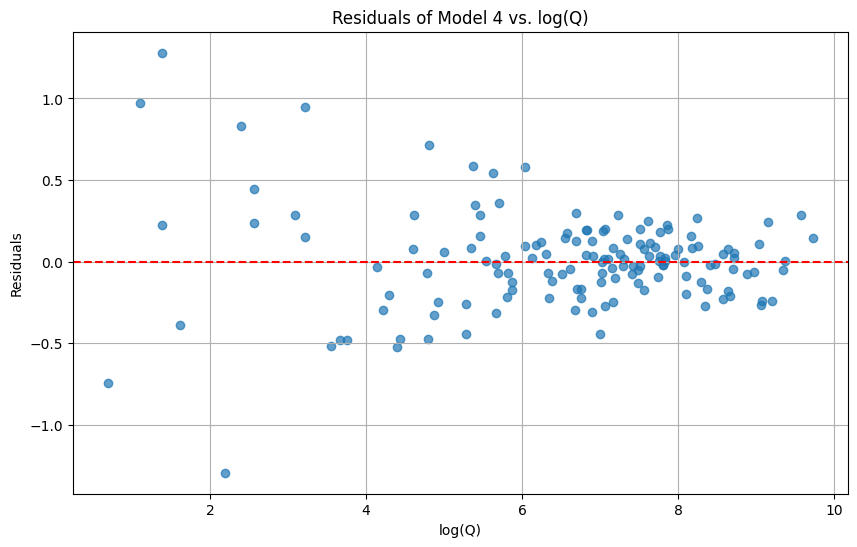

In [32]:
import matplotlib.pyplot as plt

# Calculate fitted value with respect to Model 4
fitted_values_model4 = np.dot(X_wls, beta_hat_model4) / w_i # Unweight the predictions for comparison with original y_restricted

# Calculate residuals from Model 4, based on unweighted dependent variable
residuals_model4 = y_restricted - fitted_values_model4

# Plot the residuals against log(Q)
plt.figure(figsize=(10, 6))
plt.scatter(log_q, residuals_model4, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals of Model 4 vs. log(Q)')
plt.xlabel('log(Q)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Model 4 was estimated using Generalized (Weighted) Least Squares, employing weights derived from the heteroskedasticity function $$h_i = 0.0565 + (\frac{2.1377}{Q})$$.
<br>
The estimated coefficients for Model 4 were: Intercept: $-4.12$, $log(Q)$: $0.22$, $[log(Q)]^2$: 0.05, $log(\frac{PL}{PF})$: $0.47$, and $log(\frac{PK}{PF})$: $0.13$.
<br>
The scatter plot of Model 4 residuals against $log(Q)$ indicated improved conditional homoskedasticity, with a more constant spread of residuals, suggesting the WLS approach effectively addressed the heteroskedasticity.  While some slight variation in spread might still be present, there is no strong funnel or cone shape that would indicate severe remaining increasing variance with $log(Q)$.
<br>
The residuals appeared randomly scattered around zero, with no strong systematic patterns, implying that the inclusion of the $[log(Q)]^2$ term adequately captured the nonlinear relationship between $log(\frac{TC}{PF})$ and $log(Q)$. There isn't clear evidence of unmodeled nonlinearities that would require further polynomial terms or transformations.

